In [1]:
import numpy as np
import matplotlib.pyplot as plt
import vpython as vp
import random as rd
mc = "mediumorchid"
import warnings
warnings.filterwarnings('ignore')

<IPython.core.display.Javascript object>

## Exercise 10 - Harmonic and Anharmonic Oscillator

The harmonic oscillator equation is given by

$$\frac{\text{d}^2x}{\text{d}t^2}=-\omega^2 x.$$

1. Write a program that provides the behavior of an oscillator with $\omega=1$ over the interval $t\in[0,50]$, initially displaced from rest to the position $x=1$ and then released freely. Plot its position as a function of time.

2. Increase the oscillation amplitude by raising the initial position value, and confirm that the oscillation period remains approximately constant.

3. Modify the program to describe the behavior of an anharmonic oscillator governed by the equation

    $$\frac{\text{d}^2x}{\text{d}t^2}=-\omega^2 x^3.$$

    Check what occurs when the initial amplitude is increased.  
    Plot the oscillator's velocity as a function of its position, which is known as the phase space diagram.

4. Finally, study the van der Pol oscillator (commonly found in electronic circuits and laser physics), whose equations of motion are

    $$\frac{\text{d}^2x}{\text{d}t^2}-\mu(1-x^2)\frac{\text{d}x}{\text{d}t}+\omega^2 x=0.$$

    Describe its behavior over the interval $t\in[0,20]$ for $\omega=\mu=1$ and initial conditions $x=1$, $\text{d}x/\text{d}t=0$.  
    Investigate what happens when the value of $\mu$ is increased.

5. For each case, create an animation that describes the system's behavior.

---

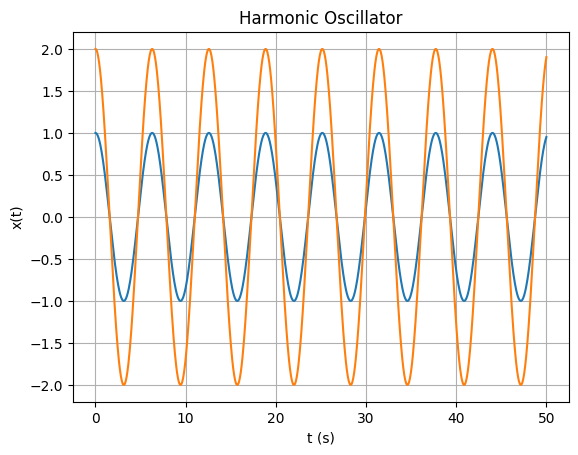

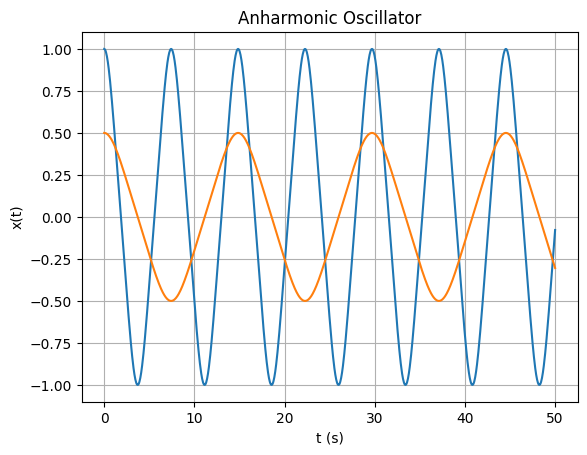

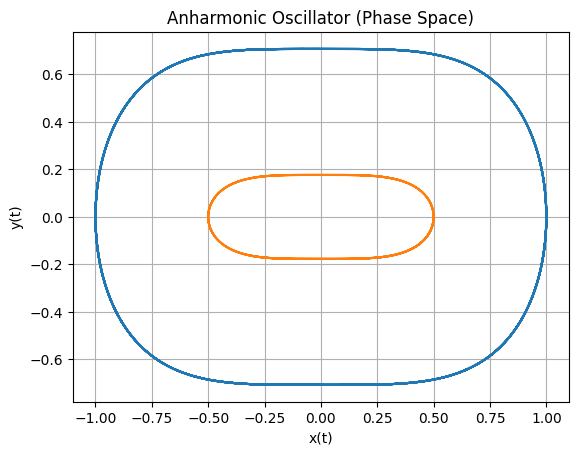

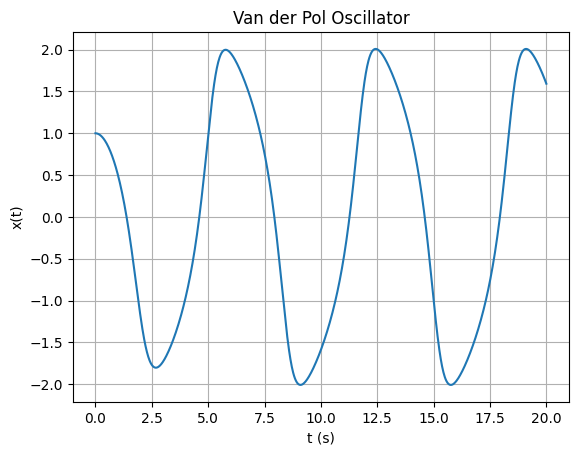

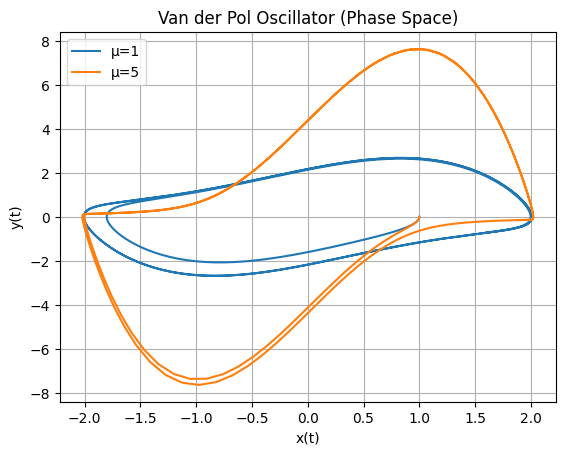

In [2]:
w = 1
mu = 1

x0, y0 = 1, 0

r = np.array([x0, y0], float)
r2 = np.array([2, 0], float)
r3 = np.array([1, 0], float)
r4 = np.array([0.5, 0], float)
r5 = np.array([1, 0], float)

def F(r, t):
    x = r[0]
    y = r[1]

    fx = y
    fy = - (w**2) * x
    return np.array([fx, fy], float)

def oscillator(F, a, b, N, r):
    h = (b - a) / N
    time = np.linspace(a, b, N)
    xp, yp = [], []
    r = np.array(r, float)

    for t in time:
        xp.append(r[0])
        yp.append(r[1])

        k1 = h * F(r, t)
        k2 = h * F(r + k1 / 2, t + h / 2)
        k3 = h * F(r + k2 / 2, t + h / 2)
        k4 = h * F(r + k3, t + h)
        r += (k1 + 2 * k2 + 2 * k3 + k4) / 6
    return time, xp, yp

t, x, vx = oscillator(F, 0, 50, 1000, r)
t2, x2, vx2 = oscillator(F, 0, 50, 1000, r2)
plt.plot(t, x)
plt.plot(t2, x2)
plt.title('Harmonic Oscillator')
plt.grid()
plt.xlabel('t (s)')
plt.ylabel('x(t)')
plt.show()

def F2(r, t):
    x = r[0]
    y = r[1]

    fx = y
    fy = - (w**2) * x**3
    return np.array([fx, fy], float)

t3, x3, y3 = oscillator(F2, 0, 50, 1000, r3)
t4, x4, y4 = oscillator(F2, 0, 50, 1000, r4)
plt.plot(t3, x3)
plt.plot(t4, x4)
plt.title('Anharmonic Oscillator')
plt.grid()
plt.xlabel('t (s)')
plt.ylabel('x(t)')
plt.show()

plt.plot(x3, y3)
plt.plot(x4, y4)
plt.title('Anharmonic Oscillator (Phase Space)')
plt.grid()
plt.xlabel('x(t)')
plt.ylabel('y(t)')
plt.show()

def F3(r, t):
    x = r[0]
    y = r[1]

    fx = y
    fy = mu * (1 - x**2) * y - (w**2) * x
    return np.array([fx, fy], float)

t5, x5, y5 = oscillator(F3, 0, 20, 1000, r5)
plt.plot(t5, x5)
plt.title('Van der Pol Oscillator')
plt.xlabel('t (s)')
plt.ylabel('x(t)')
plt.grid()
plt.show()

plt.plot(x5, y5)
mu = 5
t6, x6, y6 = oscillator(F3, 0, 20, 1000, r5)
plt.plot(x6, y6)
plt.legend(['μ=1', 'μ=5'])
plt.grid()
plt.title('Van der Pol Oscillator (Phase Space)')
plt.xlabel('x(t)')
plt.ylabel('y(t)')
plt.show()
